# Infinite-dimensional MCMC: Preconditioned Crank-Nicolson (pCN)

The pCN sampler targets distributions of the form
$$\pi(x) \propto L(x) \cdot \underbrace{\mathcal{N}(x;\,0,\,Q^{-1})}_{\text{prior}},$$
using the proposal
$$x' = \sqrt{1-\beta^2}\,x + \beta\,\xi, \quad \xi \sim \mathcal{N}(0, Q^{-1}).$$
Because $x'$ is a convex combination of $x$ and a fresh prior draw, the prior is **invariant** under the proposal. The acceptance ratio therefore involves only the likelihood:
$$\alpha = \min\!\left(1,\, \frac{L(x')}{L(x)}\right).$$
This makes the acceptance rate dimension-robust: unlike random-walk MH (which needs step size $O(n^{-1/2})$ in $\mathbb{R}^n$), pCN maintains a fixed acceptance rate as the dimension grows.

**This notebook** demonstrates pCN using:
- **Prior**: Besag CAR model on a 2-D grid, $Q = \kappa^2 I + L_{\text{graph}}$.
- **Likelihood**: constant (log-likelihood $= 0$) to start â€” samples are prior draws.
  Replace `log_likelihood` with any JAX-traceable function to target a different posterior.

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.linalg
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from pcn import pcn, PCNState, PCNInfo

## 1. Prior: Besag CAR model on a 2-D grid

Nodes are arranged on an $n \times n$ grid with 4-connectivity. The precision matrix is
$$Q = \kappa^2 I + L_{\text{graph}}, \quad L_{\text{graph}} = D - A,$$
where $D$ is the diagonal degree matrix and $A$ is the 4-neighbour adjacency matrix.
Adding $\kappa^2 I$ makes $Q$ positive definite (proper CAR); $\kappa$ controls the marginal variance and spatial range.

To sample from $\mathcal{N}(0, Q^{-1})$:
1. Compute the Cholesky factor $Q = L L^\top$.
2. Draw $z \sim \mathcal{N}(0, I)$.
3. Solve $L^\top \xi = z$ (upper-triangular back-substitution) â†’ $\xi \sim \mathcal{N}(0, Q^{-1})$.

In [2]:
n = 25          # grid side length; N = n^2 nodes total
N = n * n
kappa = 0.5     # increase -> shorter range, smaller variance

# --- Build 4-connectivity adjacency matrix ---
row_idx, col_idx = [], []
for i in range(n):
    for j in range(n):
        node = i * n + j
        for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ni_, nj_ = i + di, j + dj
            if 0 <= ni_ < n and 0 <= nj_ < n:
                row_idx.append(node)
                col_idx.append(ni_ * n + nj_)

A = sp.csr_array((np.ones(len(row_idx)), (row_idx, col_idx)), shape=(N, N))
degree  = np.asarray(A.sum(axis=1)).ravel()
L_graph = sp.diags(degree) - A
Q       = kappa**2 * sp.eye(N) + L_graph

print(f'Grid: {n}x{n} = {N} nodes,  kappa = {kappa}')

# --- JAX-traceable sparse Q mat-vec (COO scatter-add, O(nnz)) ---
Q_coo  = Q.tocoo()
Qr_j   = jnp.array(Q_coo.row,  dtype=jnp.int32)
Qc_j   = jnp.array(Q_coo.col,  dtype=jnp.int32)
Qv_j   = jnp.array(Q_coo.data)


@jax.jit
def Q_matvec(x):
    """Q x via sparse scatter-add.  O(nnz) ~ O(N) for bounded-degree graphs."""
    return jnp.zeros(N).at[Qr_j].add(Qv_j * x[Qc_j])


Grid: 25x25 = 625 nodes,  kappa = 0.5


In [3]:
import jax.scipy.sparse.linalg as jspsl


@jax.jit
def Q_solve(b):
    """Solve Q x = b via CG.  No Cholesky or dense matrix needed."""
    x, _ = jspsl.cg(Q_matvec, b, tol=1e-8, maxiter=200)
    return x


@jax.jit
def prior_sample_fn(rng_key):
    """Draw xi ~ N(0, Q^{-1}) by CG-solving Q xi = z,  z ~ N(0, I)."""
    z = jax.random.normal(rng_key, (N,))
    return Q_solve(z)


# Sanity checks
x_test = jax.random.normal(jax.random.PRNGKey(7), (N,))
err = float(jnp.max(jnp.abs(Q_solve(Q_matvec(x_test)) - x_test)))
print(f"Q_solve(Q_matvec(x)) max residual: {err:.2e}")

keys = jax.random.split(jax.random.PRNGKey(0), 2000)
samples_prior = jax.vmap(prior_sample_fn)(keys)
print(f"Prior sample mean (want ~0): {float(samples_prior.mean()):.4f}")
print(f"Prior sample std  (want ~{float(jnp.sqrt(jnp.diag(jnp.linalg.inv(jnp.array(Q.toarray()))).mean())):.3f}): {float(samples_prior.std()):.4f}")


Q_solve(Q_matvec(x)) max residual: 9.94e-08
Prior sample mean (want ~0): 0.0038
Prior sample std  (want ~0.641): 0.6573


## 2. Likelihood

Start with a **constant likelihood** (`log_likelihood = 0` everywhere).
In this case $\pi(x) = \mathcal{N}(0, Q^{-1})$ exactly, so the pCN chain samples the prior.
This is useful to verify the sampler is correct before plugging in real data.

Replace the body of `log_likelihood` with any JAX-differentiable function of `x`.

In [4]:
@jax.jit
def log_likelihood(x):
    """Log L(x). Replace this with your actual likelihood."""
    # --- constant (uninformed) likelihood ---
    return jnp.zeros(())

    # --- example: soft constraint towards a target field ---
    # target = jnp.zeros(N)   # or load from data
    # sigma_obs = 0.5
    # return -0.5 * jnp.sum((x - target)**2) / sigma_obs**2

    # --- example: LGCP Poisson log-likelihood (see inference.py) ---
    # mu = 0.0
    # return n_obs * mu + jnp.dot(data_term, x) - jnp.dot(c_lumped, jnp.exp(mu + x))

## 3. Run the pCN chain

In [5]:
beta      = 0.5
n_warmup  = 200
n_samples = 1000
seed      = 42

sampler = pcn(log_likelihood, prior_sample_fn, beta)
x0      = jnp.zeros(N)
state   = sampler.init(x0)


@jax.jit
def run_chain(state, keys):
    def step(state, key):
        state, info = sampler.step(key, state)
        return state, (state.position, info.is_accepted, info.acceptance_rate)
    return jax.lax.scan(step, state, keys)


rng = jax.random.PRNGKey(seed)

rng, subkey = jax.random.split(rng)
state, _ = run_chain(state, jax.random.split(subkey, n_warmup))

rng, subkey = jax.random.split(rng)
state, (positions, accepted, acc_rates) = run_chain(
    state, jax.random.split(subkey, n_samples)
)

positions = np.array(positions)
accepted  = np.array(accepted)
print(f"beta = {beta},  acceptance rate = {accepted.mean():.3f}")


beta = 0.5,  acceptance rate = 1.000


## 4. Visualize samples

With a constant likelihood the samples should look like independent draws from the CAR prior.

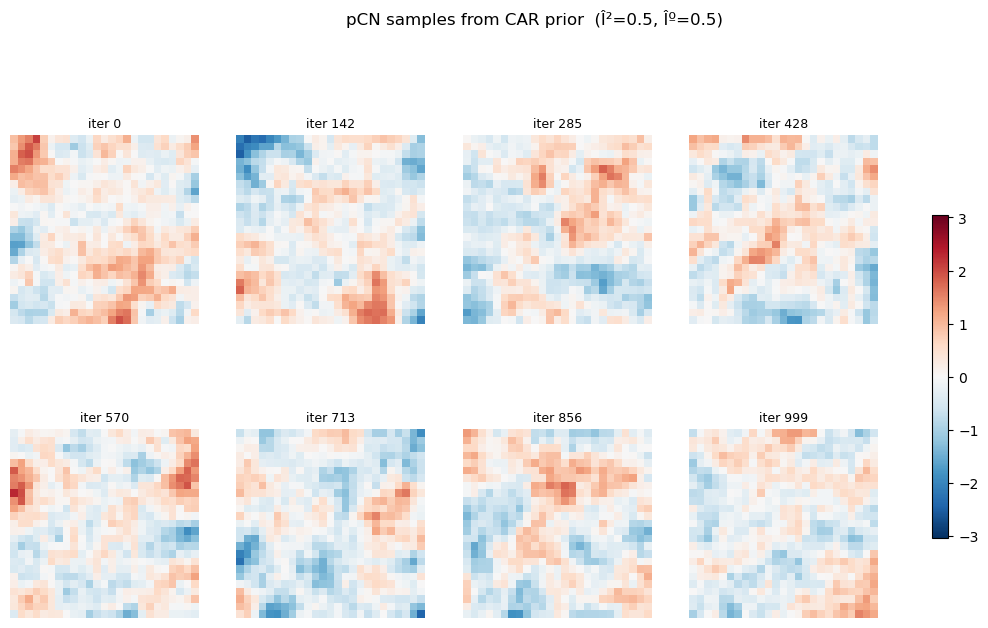

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
vmax = np.abs(positions).max() * 0.8
for ax, idx in zip(axes.flat, np.linspace(0, n_samples - 1, 8, dtype=int)):
    im = ax.imshow(positions[idx].reshape(n, n), cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"iter {idx}", fontsize=9)
    ax.axis("off")
plt.colorbar(im, ax=axes, shrink=0.6)
plt.suptitle(f"pCN samples from CAR prior  (Î²={beta}, Îº={kappa})", y=1.02)
# plt.tight_layout()
plt.show()

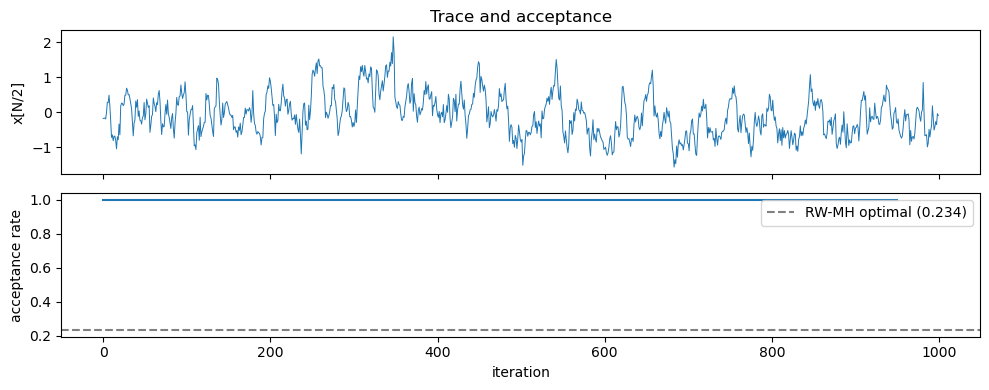

In [7]:
# Trace plot for a single node and running acceptance rate
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

ax1.plot(positions[:, N // 2], lw=0.7)
ax1.set_ylabel("x[N/2]")
ax1.set_title("Trace and acceptance")

window = 50
running_acc = np.convolve(accepted.astype(float), np.ones(window) / window, mode="valid")
ax2.plot(running_acc)
ax2.axhline(0.234, ls="--", c="gray", label="RW-MH optimal (0.234)")
ax2.set_ylabel("acceptance rate")
ax2.set_xlabel("iteration")
ax2.legend()
plt.tight_layout()
plt.show()

## 5. Tune Î²

With a constant likelihood, all proposals are accepted (acceptance rate = 1 regardless of Î²).
Once a non-trivial likelihood is plugged in, tune Î² so the acceptance rate is ~20-40%.

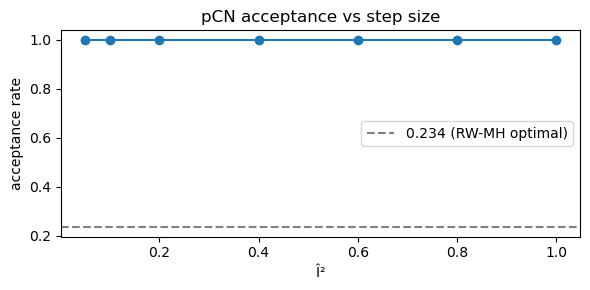

In [8]:
betas = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
mean_acc = []

for b in betas:
    s = pcn(log_likelihood, prior_sample_fn, b)
    st = s.init(x0)

    @jax.jit
    def _run(st, keys):
        def _step(st, k):
            st, info = s.step(k, st)
            return st, info.is_accepted
        return jax.lax.scan(_step, st, keys)

    keys_b = jax.random.split(jax.random.PRNGKey(0), 500)
    _, acc_b = _run(st, keys_b)
    mean_acc.append(float(np.array(acc_b).mean()))

plt.figure(figsize=(6, 3))
plt.plot(betas, mean_acc, "o-")
plt.axhline(0.234, ls="--", c="gray", label="0.234 (RW-MH optimal)")
plt.xlabel("Î²");  plt.ylabel("acceptance rate")
plt.title("pCN acceptance vs step size")
plt.legend();  plt.tight_layout();  plt.show()

## 6. Hilbert Space HMC

Hilbert space HMC uses the prior precision $Q$ as the Hamiltonian mass matrix:

$$H(x,\,p) = U(x) + K(p),\quad U(x) = -\log L(x) + \tfrac{1}{2}x^\top Q x,\quad K(p) = \tfrac{1}{2}p^\top Q^{-1}p.$$

Momentum is refreshed as $p \sim \mathcal{N}(0, Q)$ at each step.  The leapfrog integrator with step size $\varepsilon$ and $L$ steps generates a proposal; a Metropolis step corrects for discretisation error.

Because the kinetic and potential energies share the same $Q$-inner product the acceptance rate is **dimension-robust**: it does not degrade as the grid is refined, unlike vanilla HMC whose step size must shrink as $O(n^{-1/4})$.  Compared with pCN, each HMC step explores further along the posterior geometry using gradient information, at the cost of $L$ gradient evaluations per proposal.

In [9]:
from hilbert_hmc import hilbert_hmc, HilbertHMCState, HilbertHMCInfo


In [10]:
# velocity_sample_fn draws v ~ N(0, Q^{-1}), i.e. a prior draw.
# This is identical to prior_sample_fn: CG-solve Q v = z, z ~ N(0, I).
# No Cholesky or dense matrix needed.
velocity_sample_fn = prior_sample_fn

print('Q_matvec, Q_solve, and velocity_sample_fn are ready (CG-based).')


Q_matvec, Q_solve, and velocity_sample_fn are ready (CG-based).


In [11]:
step_size  = 0.1   # tune so |Delta H| is small and acceptance ~65-80%
n_leapfrog = 10

hmc_sampler = hilbert_hmc(
    log_likelihood, Q_matvec, Q_solve, velocity_sample_fn,
    step_size=step_size, n_leapfrog=n_leapfrog,
)
state_hmc = hmc_sampler.init(jnp.zeros(N))


@jax.jit
def run_hmc_chain(state, keys):
    def step(state, key):
        state, info = hmc_sampler.step(key, state)
        return state, (state.position, info.is_accepted, info.energy_change)
    return jax.lax.scan(step, state, keys)


rng_hmc = jax.random.PRNGKey(123)

rng_hmc, subkey = jax.random.split(rng_hmc)
state_hmc, _ = run_hmc_chain(state_hmc, jax.random.split(subkey, n_warmup))

rng_hmc, subkey = jax.random.split(rng_hmc)
state_hmc, (pos_hmc, acc_hmc, dH_hmc) = run_hmc_chain(
    state_hmc, jax.random.split(subkey, n_samples)
)

pos_hmc = np.array(pos_hmc)
acc_hmc = np.array(acc_hmc)
dH_hmc  = np.array(dH_hmc)
print(f"step_size={step_size}, L={n_leapfrog}  ->  acceptance rate = {acc_hmc.mean():.3f}")


step_size=0.1, L=10  ->  acceptance rate = 0.983


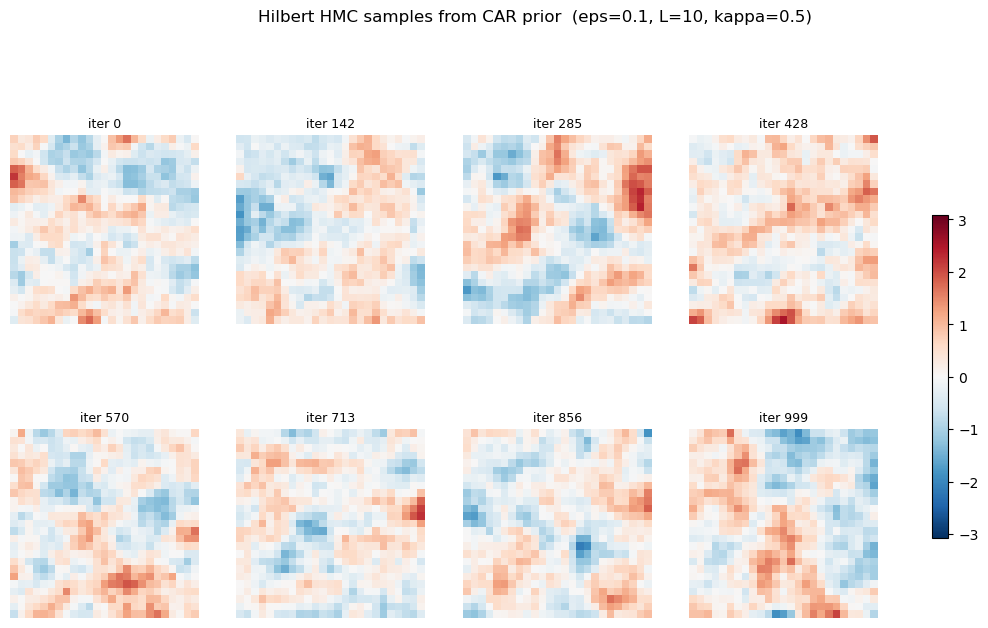

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
vmax_hmc = np.abs(pos_hmc).max() * 0.8
for ax, idx in zip(axes.flat, np.linspace(0, n_samples - 1, 8, dtype=int)):
    im = ax.imshow(
        pos_hmc[idx].reshape(n, n), cmap='RdBu_r', vmin=-vmax_hmc, vmax=vmax_hmc
    )
    ax.set_title(f'iter {idx}', fontsize=9)
    ax.axis('off')
plt.colorbar(im, ax=axes, shrink=0.6)
plt.suptitle(
    f'Hilbert HMC samples from CAR prior  (eps={step_size}, L={n_leapfrog}, kappa={kappa})',
    y=1.02,
)
# plt.tight_layout()
plt.show()


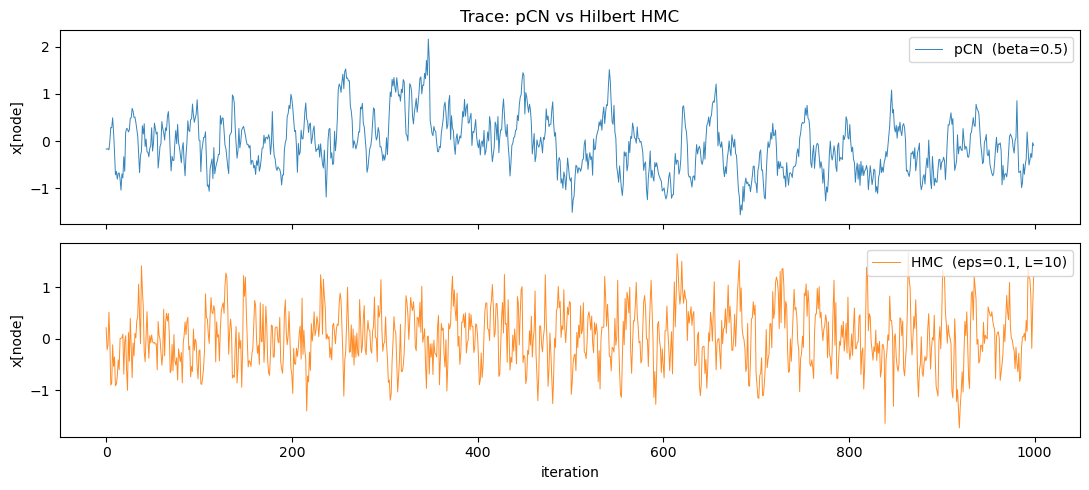

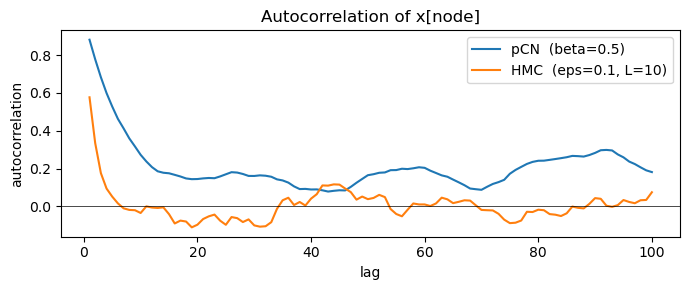

In [ ]:
# Trace + autocorrelation comparison
node = N // 2

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(positions[:, node], lw=0.7, alpha=0.9, label=f"pCN  (beta={beta})")
axes[1].plot(pos_hmc[:, node],   lw=0.7, alpha=0.9, color="C1",
             label=f"HMC  (eps={step_size}, L={n_leapfrog})")
for ax in axes:
    ax.set_ylabel("x[node]"); ax.legend(loc="upper right")
axes[0].set_title("Trace: pCN vs Hilbert HMC")
axes[1].set_xlabel("iteration")
plt.tight_layout()
plt.show()


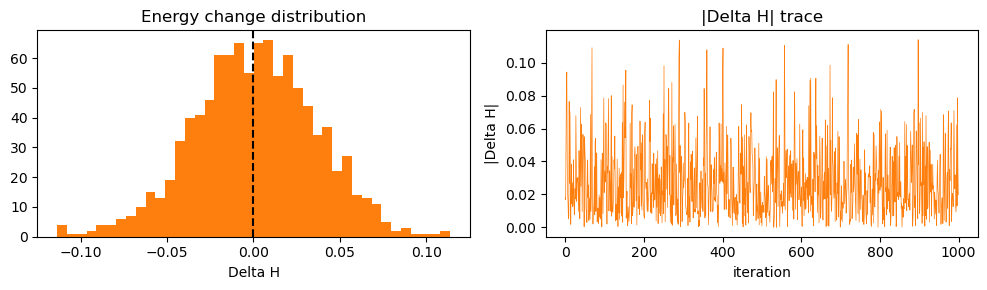

Mean |dH|: 0.0282,  max |dH|: 0.1139


In [14]:
# ΔH diagnostics: near-zero distribution means good step size.
# Large |ΔH| -> step size too large; ΔH ≡ 0 -> step size too small.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.hist(dH_hmc[np.isfinite(dH_hmc)], bins=40, color="C1")
ax1.axvline(0, c="k", ls="--")
ax1.set_xlabel("Delta H"); ax1.set_title("Energy change distribution")

ax2.plot(np.abs(dH_hmc), lw=0.5, color="C1")
ax2.set_xlabel("iteration"); ax2.set_ylabel("|Delta H|")
ax2.set_title("|Delta H| trace")

plt.tight_layout(); plt.show()
print(f"Mean |dH|: {np.abs(dH_hmc).mean():.4f},  max |dH|: {np.abs(dH_hmc).max():.4f}")


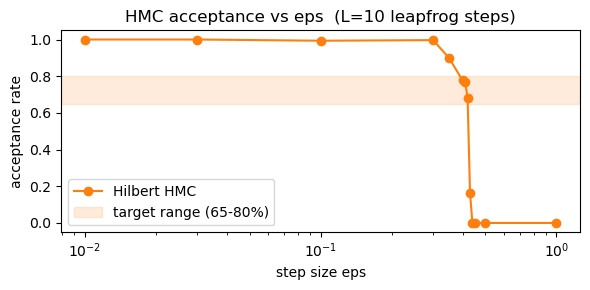

In [15]:
# Step size sweep: find eps giving ~65-80% acceptance (HMC optimal range)
step_sizes   = [0.01, 0.03, 0.1, 0.3, 0.35, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.5, 1.0]
hmc_acc_rates = []

for eps in step_sizes:
    h = hilbert_hmc(
        log_likelihood, Q_matvec, Q_solve, velocity_sample_fn,
        step_size=eps, n_leapfrog=n_leapfrog,
    )
    st_e = h.init(jnp.zeros(N))

    @jax.jit
    def _run_hmc(st, keys):
        def _step(st, k):
            st, info = h.step(k, st)
            return st, info.is_accepted
        return jax.lax.scan(_step, st, keys)

    _, acc_e = _run_hmc(st_e, jax.random.split(jax.random.PRNGKey(0), 300))
    hmc_acc_rates.append(float(np.array(acc_e).mean()))

plt.figure(figsize=(6, 3))
plt.semilogx(step_sizes, hmc_acc_rates, "o-", color="C1", label="Hilbert HMC")
plt.axhspan(0.65, 0.80, alpha=0.15, color="C1", label="target range (65-80%)")
plt.xlabel("step size eps"); plt.ylabel("acceptance rate")
plt.title(f"HMC acceptance vs eps  (L={n_leapfrog} leapfrog steps)")
plt.legend(); plt.tight_layout(); plt.show()


## 7. Resolution comparison  (step size 0.2, L = 10 leapfrog steps)

Hilbert-space HMC claims **dimension-robustness**: the acceptance rate stays roughly constant as the grid is refined, because the leapfrog step is measured in the $Q$-norm.  The compute cost per step should grow as $O(N)$ because CG with the sparse $Q$-matvec converges in $O(\sqrt{\kappa(Q)})$ iterations regardless of $N$, and each CG iteration is $O(\mathrm{nnz}) = O(N)$.


In [24]:
import time


def make_grid_ops(n_res, kappa_res=0.5):
    # Build JAX Q operators for an n_res x n_res 4-connected CAR grid
    N_res = n_res * n_res
    rows, cols = [], []
    for i in range(n_res):
        for j in range(n_res):
            nd = i * n_res + j
            for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ni_, nj_ = i + di, j + dj
                if 0 <= ni_ < n_res and 0 <= nj_ < n_res:
                    rows.append(nd)
                    cols.append(ni_ * n_res + nj_)
    A_sp = sp.csr_array(
        (np.ones(len(rows)), (rows, cols)), shape=(N_res, N_res)
    )
    Q_sp = (
        kappa_res**2 * sp.eye(N_res)
        + sp.diags(np.asarray(A_sp.sum(1)).ravel())
        - A_sp
    )
    coo = Q_sp.tocoo()
    Qr_ = jnp.array(coo.row,  dtype=jnp.int32)
    Qc_ = jnp.array(coo.col,  dtype=jnp.int32)
    Qv_ = jnp.array(coo.data)

    @jax.jit
    def Q_mv(x):
        return jnp.zeros(N_res).at[Qr_].add(Qv_ * x[Qc_])

    @jax.jit
    def Q_slv(b):
        x, _ = jspsl.cg(Q_mv, b, tol=1e-8, maxiter=200)
        return x

    @jax.jit
    def vel_fn(rng_key):
        return Q_slv(jax.random.normal(rng_key, (N_res,)))

    return Q_mv, Q_slv, vel_fn, N_res


# ── Resolution sweep ──────────────────────────────────────────────────────────
grid_sizes   = [10, 20, 50, 100, 200]
step_size_r  = 0.5          # base step size; user scales by N^(1/4) per resolution
n_leapfrog_r = 5
n_warmup_r   = 500
n_eval_r     = 200

records = []

for n_r in grid_sizes:
    N_r = n_r * n_r
    eps_r = step_size_r / N_r**0.25  # scale step size by N^(-1/4)
    print(f'n={n_r:3d}  N={N_r:6d}  eps={eps_r:.3f}  ... ', end='', flush=True)

    Q_mv_r, Q_slv_r, vel_r, _ = make_grid_ops(n_r, kappa_res=kappa)

    # Track the value at the center node across all steps
    center_node = (n_r // 2) * n_r + (n_r // 2)

    hmc_r = hilbert_hmc(
        log_likelihood, Q_mv_r, Q_slv_r, vel_r,
        step_size=eps_r, n_leapfrog=int(n_leapfrog_r*N_r**(1/4)),
    )

    @jax.jit
    def run_r(state, keys):
        def _step(state, key):
            state, info = hmc_r.step(key, state)
            return state, (
                info.is_accepted,
                info.energy_change,
                state.position[center_node],   # scalar trace
            )
        return jax.lax.scan(_step, state, keys)

    st_r = hmc_r.init(jnp.zeros(N_r))

    # Warmup (triggers JIT compilation)
    st_r, _ = run_r(st_r, jax.random.split(jax.random.PRNGKey(n_r), n_warmup_r))
    jax.block_until_ready(st_r.position)

    # Timed evaluation
    t0 = time.perf_counter()
    st_r, (acc_r, dH_r, trace_r) = run_r(
        st_r, jax.random.split(jax.random.PRNGKey(n_r + 1000), n_eval_r)
    )
    jax.block_until_ready(acc_r)
    elapsed = time.perf_counter() - t0

    acc_val = float(np.array(acc_r).mean())
    dH_val  = float(np.abs(np.array(dH_r)).mean())
    ms_val  = 1000.0 * elapsed / n_eval_r

    records.append(dict(
        n=n_r, N=N_r, eps=eps_r,
        accept=acc_val, mean_abs_dH=dH_val, ms_per_step=ms_val,
        trace=np.array(trace_r),           # (n_eval_r,) center-node values
        center_node=center_node,
    ))
    print(f'accept={acc_val:.3f}  mean|dH|={dH_val:.4f}  {ms_val:.2f} ms/step')


n= 10  N=   100  eps=0.158  ... accept=0.985  mean|dH|=0.0273  3.84 ms/step
n= 20  N=   400  eps=0.112  ... accept=0.985  mean|dH|=0.0209  8.20 ms/step
n= 50  N=  2500  eps=0.071  ... accept=0.995  mean|dH|=0.0202  50.56 ms/step
n=100  N= 10000  eps=0.050  ... accept=1.000  mean|dH|=0.0196  320.89 ms/step
n=200  N= 40000  eps=0.035  ... accept=0.985  mean|dH|=0.0209  1775.63 ms/step


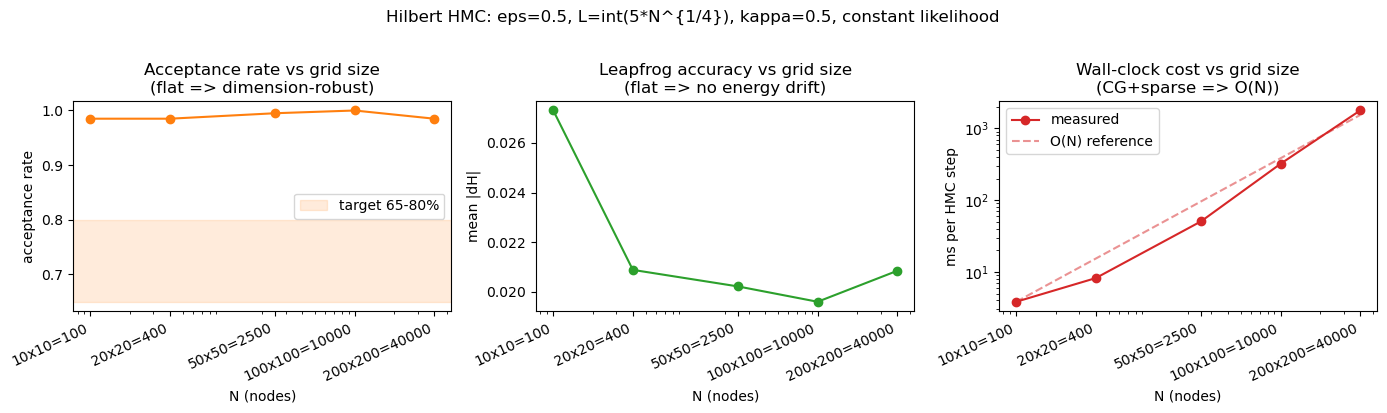

     n        N    accept    mean|dH|    ms/step
--------------------------------------------------
    10      100     0.985     0.02731       3.84
    20      400     0.985     0.02089       8.20
    50     2500     0.995     0.02022      50.56
   100    10000     1.000     0.01961     320.89
   200    40000     0.985     0.02085    1775.63


In [25]:
Ns     = [r['N']           for r in records]
ns     = [r['n']           for r in records]
accs   = [r['accept']      for r in records]
dHs    = [r['mean_abs_dH'] for r in records]
mss    = [r['ms_per_step'] for r in records]
labels = [f'{n}x{n}={n**2}' for n in ns]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ── Acceptance rate (key dimension-robustness plot) ───────────────────────────
axes[0].semilogx(Ns, accs, 'o-', color='C1')
axes[0].axhspan(0.65, 0.80, alpha=0.15, color='C1', label='target 65-80%')
axes[0].set_xlabel('N (nodes)')
axes[0].set_ylabel('acceptance rate')
axes[0].set_title('Acceptance rate vs grid size\n(flat => dimension-robust)')
axes[0].set_xticks(Ns)
axes[0].set_xticklabels(labels, rotation=25, ha='right')
axes[0].legend()

# ── Leapfrog accuracy ─────────────────────────────────────────────────────────
axes[1].semilogx(Ns, dHs, 'o-', color='C2')
axes[1].set_xlabel('N (nodes)')
axes[1].set_ylabel('mean |dH|')
axes[1].set_title('Leapfrog accuracy vs grid size\n(flat => no energy drift)')
axes[1].set_xticks(Ns)
axes[1].set_xticklabels(labels, rotation=25, ha='right')

# ── Wall-clock runtime ────────────────────────────────────────────────────────
axes[2].loglog(Ns, mss, 'o-', color='C3', label='measured')
N_arr  = np.array(Ns, dtype=float)
ms_ref = np.array(mss[0]) * N_arr / Ns[0]
axes[2].loglog(Ns, ms_ref, '--', color='C3', alpha=0.5, label='O(N) reference')
axes[2].set_xlabel('N (nodes)')
axes[2].set_ylabel('ms per HMC step')
axes[2].set_title('Wall-clock cost vs grid size\n(CG+sparse => O(N))')
axes[2].legend()
axes[2].set_xticks(Ns)
axes[2].set_xticklabels(labels, rotation=25, ha='right')

plt.suptitle(
    f'Hilbert HMC: eps={step_size_r}, L=int({n_leapfrog_r}*N^{{1/4}}), kappa={kappa}, constant likelihood',
    y=1.02,
)
plt.tight_layout()
plt.show()

# Numeric summary table
print(f'{"n":>6}  {"N":>7}  {"accept":>8}  {"mean|dH|":>10}  {"ms/step":>9}')
print('-' * 50)
for r in records:
    print(f'{r["n"]:6d}  {r["N"]:7d}  {r["accept"]:8.3f}  {r["mean_abs_dH"]:10.5f}  {r["ms_per_step"]:9.2f}')


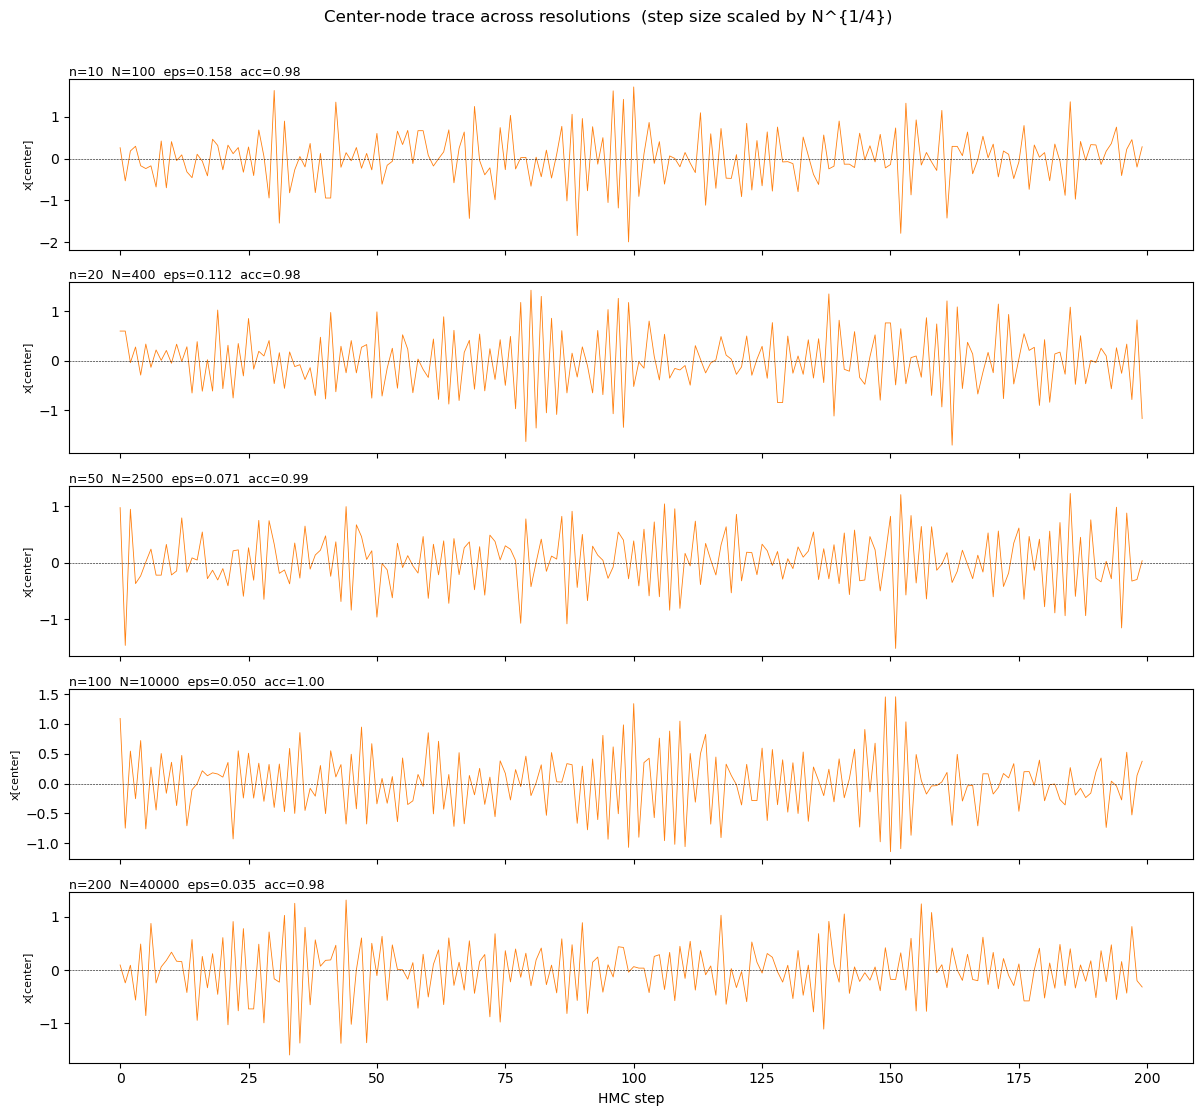

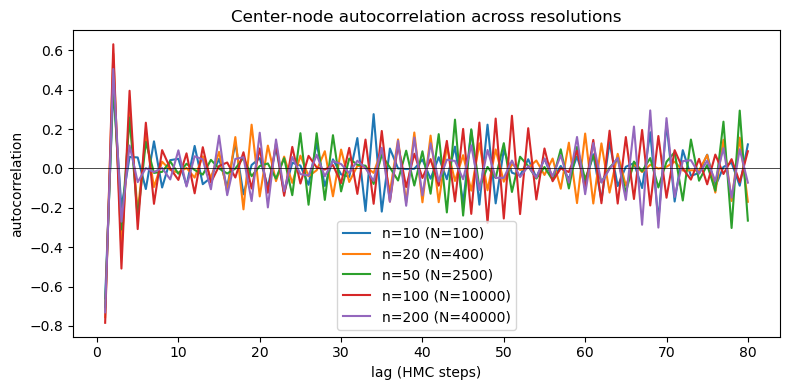

In [26]:
# One row per resolution; x-axis is HMC step, y-axis is x at the center node.
# With a constant likelihood the target is the prior, so the chain should look
# like correlated noise centred at 0.  Better mixing shows as faster decorrelation.
fig, axes = plt.subplots(
    len(records), 1,
    figsize=(12, 2.2 * len(records)),
    sharex=True,
)

for ax, r in zip(axes, records):
    ax.plot(r['trace'], lw=0.6, color='C1')
    ax.axhline(0, color='k', lw=0.4, ls='--')
    ax.set_ylabel('x[center]', fontsize=8)
    label = (
        f"n={r['n']}  N={r['N']}  "
        f"eps={r['eps']:.3f}  "
        f"acc={r['accept']:.2f}"
    )
    ax.set_title(label, fontsize=9, loc='left', pad=2)

axes[-1].set_xlabel('HMC step')
plt.suptitle(
    'Center-node trace across resolutions'
    '  (step size scaled by N^{1/4})',
    y=1.01,
)
plt.tight_layout()
plt.show()

# Autocorrelation comparison on the same axes
def autocorr(x, max_lag=80):
    x = x - x.mean()
    v = np.var(x)
    if v == 0:
        return np.zeros(max_lag)
    return np.array([np.mean(x[:-k] * x[k:]) / v for k in range(1, max_lag + 1)])

lag = np.arange(1, 81)
fig, ax = plt.subplots(figsize=(8, 4))
for i, r in enumerate(records):
    ac = autocorr(r['trace'])
    ax.plot(lag, ac, label=f"n={r['n']} (N={r['N']})", lw=1.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('lag (HMC steps)')
ax.set_ylabel('autocorrelation')
ax.set_title('Center-node autocorrelation across resolutions')
ax.legend()
plt.tight_layout()
plt.show()
